In [11]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

### Import Library

Pada tahap ini, kita mengimpor semua library yang dibutuhkan untuk menjalankan proyek pengolahan citra dan klasifikasi. Berikut penjelasan dari masing-masing library
os: Untuk interaksi dengan sistem file (misalnya membaca direktori).

cv2 (OpenCV): Digunakan untuk membaca, memproses, dan manipulasi gambar.

matplotlib.pyplot: Untuk menampilkan visualisasi gambar dan grafik.

numpy: Digunakan untuk operasi numerik dan manipulasi array.

pandas: Untuk memproses dan menganalisis data dalam bentuk tabel.

sklearn.model_selection: Untuk melakukan pembagian data dan validasi model.

sklearn.metrics: Untuk mengukur performa model (akurasi, precision, recall, dll).

skimage.feature: Untuk ekstraksi fitur dari gambar seperti GLCM (gray-level co-occurrence matrix).

scipy.stats: Untuk fungsi statistik seperti entropi.

sklearn.ensemble, svm, dan neighbors: Kumpulan algoritma klasifikasi seperti Random Forest, SVM, dan KNN.

seaborn: Untuk visualisasi data yang lebih interaktif dan menarik.



In [21]:
def resize_image(img_path, size):
    try:
        img = cv.imread(img_path)
        if img is None:
            raise ValueError(f"Image at {img_path} could not be read.")
        resized_img = cv.resize(img, size)
        return resized_img
    except Exception as e:
        print(f"Error resizing image {img_path}: {e}")
        return None

## Data Loading

Loading dataset...
Dataset loaded with 210 images across 3 classes.


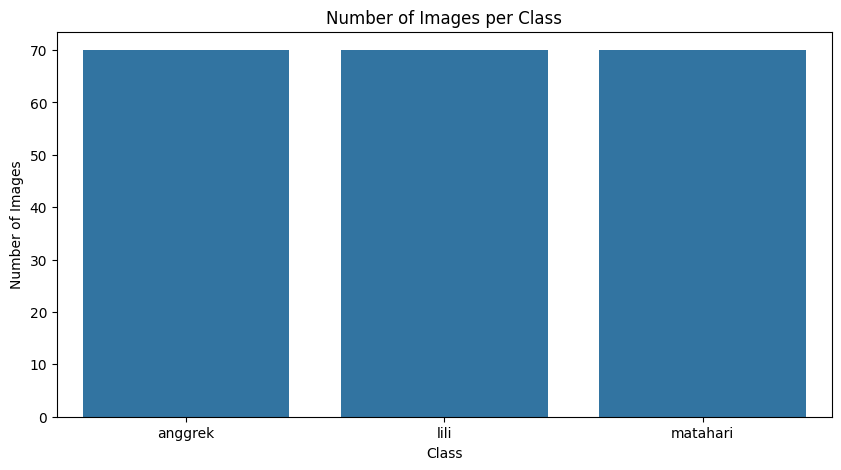

In [12]:
def load_dataset(dir):
    size = (250,250)
    images = []
    labels = []
    class_names = os.listdir(dir)
    class_counter = {class_name: 0 for class_name in class_names}

    for label, class_name in enumerate(class_names):
        class_dir = os.path.join(dir, class_name)
        if os.path.isdir(class_dir):
            for file_name in os.listdir(class_dir):
                if class_counter[class_name] >= 100:
                    break
                img_path = os.path.join(class_dir, file_name)
                img = resize_image(img_path, size)
                if img is not None:
                    images.append(img)
                    labels.append(class_name)
                    class_counter[class_name]+=1
    return np.array(images), np.array(labels), class_names, class_counter


print("Loading dataset...")
images, labels, class_names, class_counter = load_dataset('dataset')
print(f"Dataset loaded with {len(images)} images across {len(class_names)} classes.")
# Diagram Dataset
plt.figure(figsize=(10, 5))
sns.barplot(x=list(class_counter.keys()), y=list(class_counter.values()))
plt.title('Number of Images per Class')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.savefig('dataset_distribution.png')
plt.show()

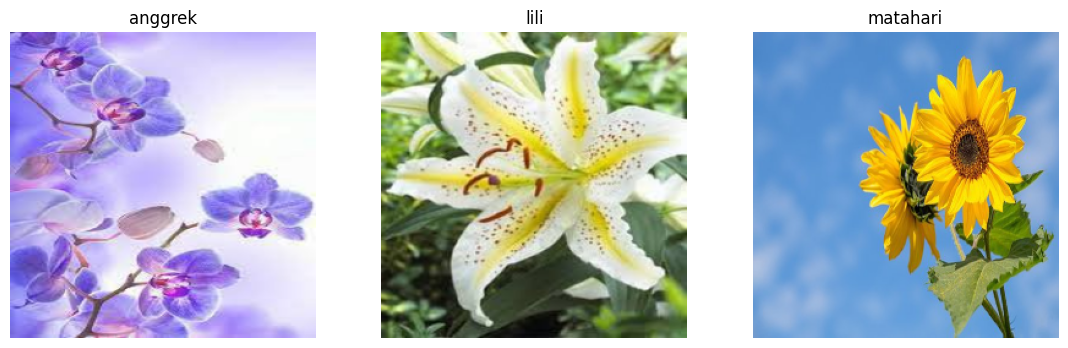

In [13]:
# Menampilkan gambar sample dari setiap kelas
def show_sample_images(images, labels, class_names):
    plt.figure(figsize=(15, 10))
    for i, class_name in enumerate(class_names):
        class_images = images[labels == class_name]
        if len(class_images) > 0:
            plt.subplot(3, 4, i + 1)
            plt.imshow(cv.cvtColor(class_images[10], cv.COLOR_BGR2RGB))
            plt.title(class_name)
            plt.axis('off')
    plt.tight_layout()
    plt.show()
show_sample_images(images, labels, class_names)

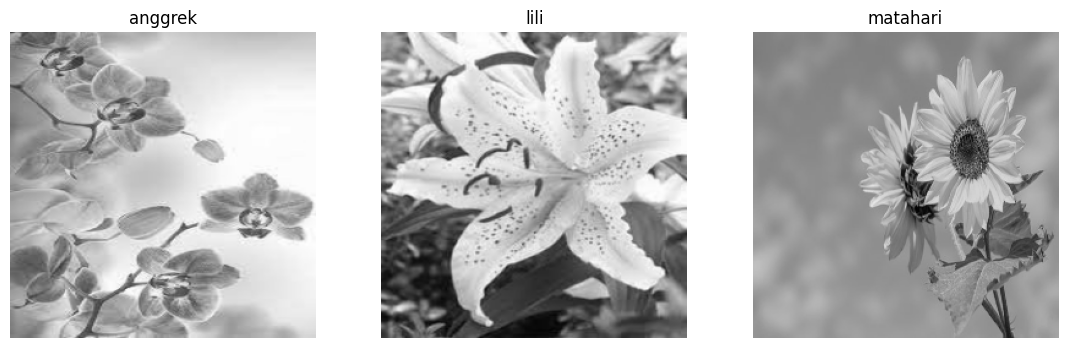

In [15]:
img_grey = []
for img in images:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_grey.append(gray)
img_grey = np.array(img_grey)

show_sample_images(img_grey, labels, class_names)

In [22]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

Kode di atas adalah fungsi `glcm(image, derajat)` yang digunakan untuk menghasilkan matriks GLCM (_Gray Level Co-occurrence Matrix_). Parameter `derajat` digunakan untuk menentukan arah perhitungan hubungan antar piksel: 0 derajat (horizontal), 45 derajat (diagonal kanan atas), 90 derajat (vertikal), atau 135 derajat (diagonal kiri atas). Jika `derajat` bernilai 0, maka sudut arah piksel diset menjadi 0 radian yang mewakili arah horizontal. Jika bernilai 45, maka arah piksel diatur menjadi π/4 radian yang menunjuk ke arah diagonal kanan atas. Untuk derajat 90, arah piksel diatur menjadi π/2 radian, sedangkan untuk 135 derajat, sudutnya menjadi 3π/4 radian. Apabila nilai derajat yang diberikan tidak termasuk ke dalam empat nilai yang valid, maka program akan menampilkan pesan _error_.
Setelah menentukan arah, fungsi akan memanggil `graycomatrix()` dari pustaka `skimage.feature`. Fungsi ini menghitung GLCM dari citra image dengan jarak antar piksel sebesar 1 piksel dan arah sesuai dengan `angles`. Parameter tambahan seperti 256 menunjukkan jumlah level keabuan dalam gambar (0 hingga 255),` symmetric=True` agar matriks simetris, dan `normed=True` agar hasilnya dinormalisasi.

### Ekstraksi Fitur: GLCM

Tahap ini menggunakan metode GLCM (Gray Level Co-occurrence Matrix) untuk mengambil fitur tekstur dari gambar.

#### Cara Kerja:
Fungsi menerima gambar grayscale dan sudut.

Sudut diubah ke radian agar bisa diproses oleh graycomatrix.

Hasilnya adalah matriks GLCM, yang digunakan untuk mengambil fitur seperti kontras, homogenitas, energi, dan lainnya.

In [23]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

##### Ekstraksi Fitur: Correlation

Tahap ini untuk mengambil nilai correlation dari matriks GLCM yang sudah dibuat sebelumnya.

Cara Kerja:
Fungsi menerima matriks GLCM hasil dari proses sebelumnya.

Menggunakan graycoprops untuk mengambil nilai correlation.

Nilai ini menunjukkan hubungan antar piksel di dalam gambar.

In [24]:
def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

##### Ekstraksi Fitur: Dissimilarity

Tahap ini mengambil nilai dissimilarity dari matriks GLCM.

Cara Kerja:
Fungsi menerima matriks GLCM sebagai input.

Menggunakan graycoprops untuk mendapatkan nilai dissimilarity.

Nilai ini mengukur seberapa berbeda intensitas piksel yang berdekatan.

In [25]:
def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

##### Ekstraksi Fitur: Homogeneity
Tahap ini mengambil nilai homogeneity dari matriks GLCM.

Cara Kerja:
Fungsi menerima matriks GLCM sebagai input.

Menggunakan graycoprops untuk mendapatkan nilai homogeneity.

Nilai ini mengukur seberapa mirip intensitas piksel yang berdekatan.

In [26]:
def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

##### Fungsi Ekstraksi Fitur: Contrast

Fungsi ini menerima sebuah matriks GLCM sebagai input.
Lalu, fungsi memanggil graycoprops dengan parameter 'contrast' untuk menghitung nilai kontras dari tekstur gambar tersebut.

Nilai contrast menunjukkan seberapa besar variasi intensitas piksel di gambar.
Semakin tinggi nilainya, semakin besar perbedaan intensitas antar piksel di gambar.


In [27]:
def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

##### Fungsi ASM (Angular Second Moment)
Fungsi ini menghitung nilai ASM dari matriks GLCM.

Cara Kerja:
Fungsi memanggil graycoprops dengan parameter 'ASM' untuk mendapatkan nilai Angular Second Moment.

Nilai ASM menunjukkan tingkat keteraturan atau homogenitas tekstur pada gambar.
Semakin tinggi nilainya, berarti tekstur gambar semakin seragam dan teratur.

In [28]:
def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

##### Fungsi Energy
Fungsi ini menghitung nilai Energy dari matriks GLCM.

Cara Kerja:
Fungsi memanggil graycoprops dengan parameter 'energy' untuk mendapatkan nilai energy tekstur pada gambar.

Nilai Energy menunjukkan kekuatan atau intensitas tekstur.
Semakin tinggi nilainya, berarti tekstur gambar lebih kuat dan teratur.

In [29]:
def entropyGlcm(matriks):
    return entropy(matriks.ravel())

##### Fungsi Entropy pada GLCM
Fungsi ini menghitung nilai Entropy dari matriks GLCM.

Nilai Entropy menunjukkan seberapa acak atau kompleks tekstur pada gambar.
Semakin tinggi nilai Entropy, semakin kompleks teksturnya.
Fitur ini membantu membedakan jenis tekstur dalam analisis citra.

In [31]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(img_grey)):
    D0 = glcm(img_grey[i], 0)
    D45 = glcm(img_grey[i], 45)
    D90 = glcm(img_grey[i], 90)
    D135 = glcm(img_grey[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

##### Ekstraksi Fitur GLCM pada Beberapa Sudut
Kode ini menghitung matriks GLCM dari setiap gambar hasil median filter (img_median) pada 4 sudut berbeda: 0°, 45°, 90°, dan 135°.

Cara Kerja:

Untuk setiap gambar, fungsi glcm dipanggil dengan sudut 0, 45, 90, dan 135 derajat.

Hasil matriks GLCM untuk masing-masing sudut disimpan ke dalam list terpisah (Derajat0, Derajat45, Derajat90, dan Derajat135).

Kenapa Dilakukan?
Mengambil GLCM dari beberapa sudut bertujuan agar fitur tekstur yang diambil lebih lengkap dan akurat, karena tekstur bisa berbeda tergantung arah pengamatan.

In [ ]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

##### Inisialisasi List untuk Menyimpan Fitur GLCM
Kode ini membuat beberapa list kosong untuk menyimpan nilai fitur tekstur dari matriks GLCM pada setiap sudut (0°, 45°, 90°, 135°).

List yang dibuat meliputi:

Kontras (contrast)

Dissimilarity

Homogenitas (homogeneity)

Entropy

ASM (Angular Second Moment)

Energi (energy)

Korelasi (correlation)

Setiap list disiapkan untuk keempat sudut, sehingga hasil ekstraksi fitur nantinya dapat dipisahkan berdasarkan arah sudut GLCM.

In [33]:
for i in range(len(img_grey)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

##### Ekstraksi Fitur Korelasi dari Matriks GLCM
Pada kode ini, dilakukan ekstraksi fitur korelasi dari setiap matriks GLCM pada keempat sudut (0°, 45°, 90°, dan 135°).

Cara Kerja:

Melakukan iterasi pada seluruh gambar median (img_median).

Untuk setiap gambar, mengambil nilai korelasi dari matriks GLCM yang sudah dibuat untuk setiap sudut.

Nilai korelasi tersebut kemudian disimpan ke list yang sesuai berdasarkan sudutnya (correlation0, correlation45, correlation90, correlation135).

Fitur korelasi ini berguna untuk mengukur sejauh mana intensitas piksel berhubungan satu sama lain pada arah tertentu di gambar, yang membantu dalam analisis tekstur gambar.

In [34]:
for i in range(len(img_grey)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

##### Ekstraksi Fitur Kontras dari GLCM
Kode ini mengambil nilai kontras dari matriks GLCM pada sudut 0°, 45°, 90°, dan 135° untuk setiap gambar.

Cara Kerja:

Loop semua gambar.

Ambil nilai kontras dari GLCM di setiap sudut.

Simpan hasilnya di list yang sesuai.

Kontras menunjukkan perbedaan intensitas di gambar, membantu mengenali tekstur dan detail.

In [35]:
for i in range(len(img_grey)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

##### Ekstraksi Fitur Dissimilarity dari GLCM
Kode ini mengambil nilai dissimilarity dari matriks GLCM pada sudut 0°, 45°, 90°, dan 135° untuk setiap gambar.

Cara Kerja:

Melakukan perulangan untuk semua gambar.

Mengambil nilai dissimilarity dari GLCM di tiap sudut.

Menyimpan hasil ke dalam list yang sesuai.

Dissimilarity mengukur perbedaan intensitas antar piksel, membantu dalam mengenali variasi tekstur pada gambar.

In [36]:
for i in range(len(img_grey)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

##### Ekstraksi Fitur Homogeneity dari GLCM
Kode ini mengambil nilai homogeneity dari matriks GLCM pada sudut 0°, 45°, 90°, dan 135° untuk setiap gambar.

Cara Kerja:

Melakukan perulangan untuk semua gambar.

Mengambil nilai homogeneity dari GLCM di tiap sudut.

Menyimpan hasilnya ke list yang sesuai.

Homogeneity mengukur seberapa mirip intensitas piksel yang berdekatan, berguna untuk mendeteksi tekstur halus pada gambar.

In [37]:
for i in range(len(img_grey)):
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

##### Ekstraksi Fitur Entropy dari GLCM
Kode ini menghitung nilai entropy dari matriks GLCM pada sudut 0°, 45°, 90°, dan 135° untuk setiap gambar.

Cara Kerja:

Melakukan perulangan untuk semua gambar.

Menghitung entropy dari GLCM di tiap sudut.

Menyimpan hasilnya ke list yang sesuai.

Entropy mengukur tingkat ketidakteraturan atau kompleksitas tekstur dalam gambar, berguna untuk membedakan pola tekstur yang berbeda.

In [38]:
for i in range(len(img_grey)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

##### Ekstraksi Fitur ASM (Angular Second Moment) dari GLCM
Kode ini menghitung nilai ASM dari matriks GLCM pada sudut 0°, 45°, 90°, dan 135° untuk setiap gambar.

Cara Kerja:

Melakukan perulangan untuk semua gambar.

Menghitung ASM dari GLCM di tiap sudut.

Menyimpan hasilnya ke list yang sesuai.

ASM mengukur homogenitas tekstur dan energi gambar, berguna untuk mengidentifikasi pola yang seragam atau berulang.

In [39]:
for i in range(len(img_grey)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

##### Ekstraksi Fitur Energy dari GLCM
Kode ini menghitung nilai Energy dari matriks GLCM pada sudut 0°, 45°, 90°, dan 135° untuk setiap gambar.

Cara Kerja:

Looping untuk setiap gambar.

Hitung energy dari GLCM di tiap sudut.

Simpan hasil ke dalam list masing-masing sudut.

Energy mengukur kekuatan atau intensitas tekstur, berguna untuk membedakan tekstur halus dan kasar pada gambar.

### Write the extraction's results to CSV

In [40]:
dataTable = {'Filename': [f'Image_{i+1}' for i in range(len(img_grey))],
        'Class': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_pros2.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_pros2.csv')
hasilEkstrak = hasilEkstrak.drop(columns=['Filename'])
x = hasilEkstrak.drop(columns=['Class'])
y = hasilEkstrak['Class']

##### Menyimpan dan Menyiapkan Data Fitur
Kode ini membuat tabel data fitur hasil ekstraksi, menyimpannya dalam file CSV, lalu memuat kembali data untuk analisis.

Langkah-langkah:

Membuat dictionary dataTable yang berisi nama file, kelas, dan semua fitur tekstur dari berbagai sudut.

Mengubah dictionary menjadi DataFrame pandas.

Menyimpan DataFrame ke file CSV bernama hasil_ekstraksi_pros2.csv.

Membaca kembali data dari file CSV.

Menghapus kolom Filename yang tidak diperlukan untuk proses berikutnya.

Memisahkan fitur (variabel x) dan label kelas (variabel y) untuk proses machine learning atau analisis lebih lanjut.

### Features Selection

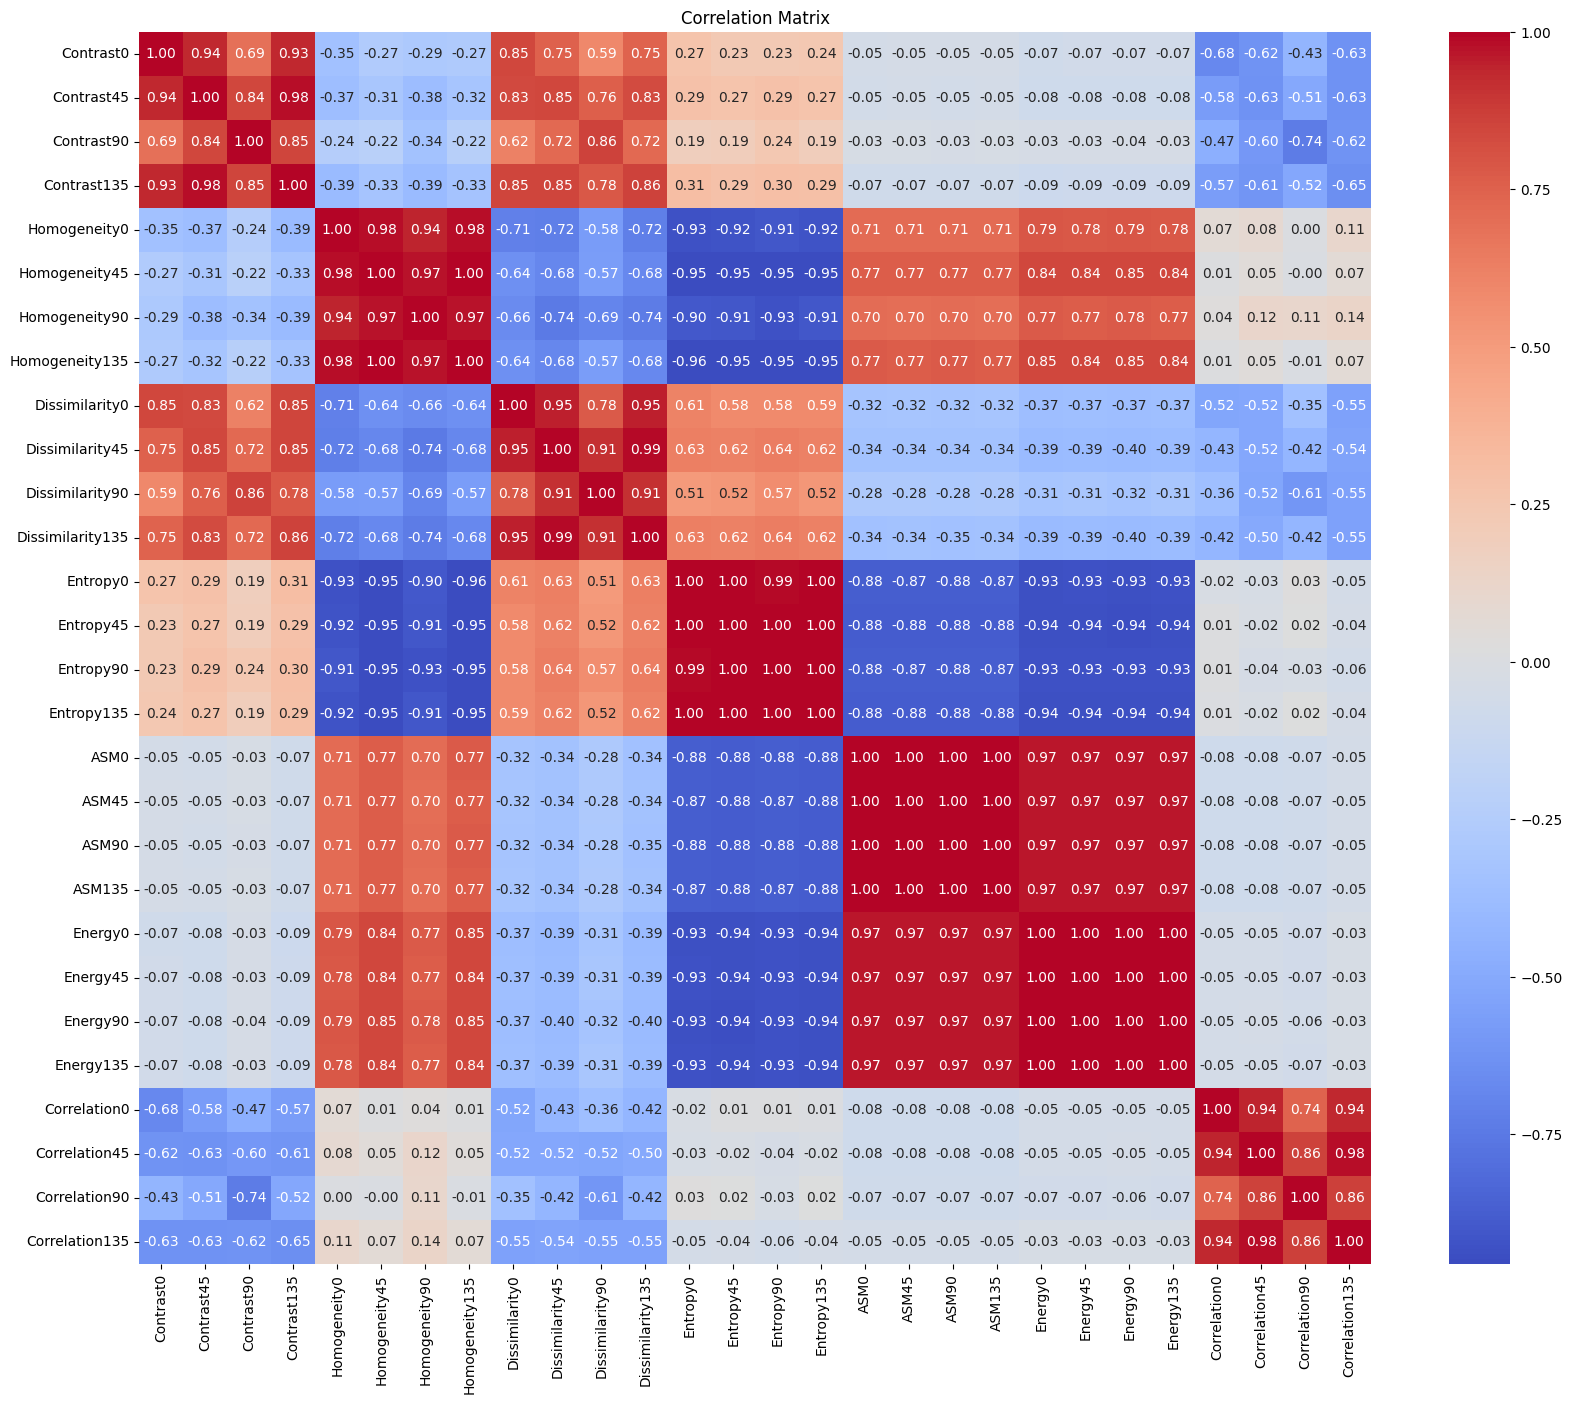

In [41]:
# Menghitung Korelasi
correlation_matrix = x.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.savefig('correlation_matrix2.png')
plt.show()

## Splitting Data

##### Membagi Data: Train dan Test
Kode ini membagi data fitur dan label menjadi dua bagian, yaitu data untuk pelatihan (training) dan data untuk pengujian (testing).

Penjelasan:
test_size=0.3 artinya 30% data digunakan untuk testing, dan sisanya 70% untuk training.

Kamu bisa sesuaikan nilai test_size sesuai kebutuhan, misalnya 0.2 untuk split 80% training dan 20% testing.

random_state=42 digunakan supaya pembagian data konsisten saat dijalankan ulang.

Hasil pembagian data dicetak agar kita tahu berapa banyak data di training dan testing.

In [42]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
print(f"Training set size: {len(x_train)}, Test set size: {len(x_test)}")
print(f"Training set size: {len(y_train)}, Test set size: {len(y_test)}")

Training set size: 147, Test set size: 63
Training set size: 147, Test set size: 63


## Feature Normalization

berikut metode normalisasi yang bisa digunakan:
- Min-Max Scaling
- Standardization (Z-score)
- Robust Scaling
- MaxAbsScaler
- dll

berikut contoh menggunakan Standardization (Z-score):

In [43]:
# normalisasi mean std
def normalize_data(data):
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    normalized_data = (data - mean) / std
    return normalized_data
x_train = normalize_data(x_train)
x_test = normalize_data(x_test)

## Modeling

### Define Model

In [44]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

##### Definisi Model dan Evaluasi Klasifikasi
Kode ini mendefinisikan fungsi untuk mengevaluasi hasil prediksi dan juga membuat beberapa model klasifikasi yang akan digunakan.

Fungsi generateClassificationReport
Menerima data asli (y_true) dan hasil prediksi (y_pred).

Menampilkan laporan klasifikasi lengkap (precision, recall, f1-score).

Menampilkan confusion matrix untuk melihat detail kesalahan prediksi.

Menampilkan akurasi sebagai ukuran kinerja model.

Model yang Didefinisikan:
Random Forest (rf): Model ensemble dengan 5 pohon keputusan.

SVM (svm): Support Vector Machine dengan kernel RBF.

KNN (knn): K-Nearest Neighbors dengan jumlah tetangga 5.

In [45]:
# Train Random Forest Classifier
rf.fit(x_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(x_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(x_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

     anggrek       0.92      0.94      0.93        50
        lili       0.94      0.96      0.95        49
    matahari       0.93      0.90      0.91        48

    accuracy                           0.93       147
   macro avg       0.93      0.93      0.93       147
weighted avg       0.93      0.93      0.93       147

[[47  1  2]
 [ 1 47  1]
 [ 3  2 43]]
Accuracy: 0.9319727891156463

------Testing Set------
              precision    recall  f1-score   support

     anggrek       0.42      0.65      0.51        20
        lili       0.58      0.52      0.55        21
    matahari       0.46      0.27      0.34        22

    accuracy                           0.48        63
   macro avg       0.49      0.48      0.47        63
weighted avg       0.49      0.48      0.46        63

[[13  4  3]
 [ 6 11  4]
 [12  4  6]]
Accuracy: 0.47619047619047616


### Train SVM Classifier

In [46]:
# Train SVM Classifier
svm.fit(x_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(x_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(x_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     anggrek       0.64      0.70      0.67        50
        lili       0.76      0.65      0.70        49
    matahari       0.68      0.71      0.69        48

    accuracy                           0.69       147
   macro avg       0.69      0.69      0.69       147
weighted avg       0.69      0.69      0.69       147

[[35  6  9]
 [10 32  7]
 [10  4 34]]
Accuracy: 0.6870748299319728

------Testing Set------
              precision    recall  f1-score   support

     anggrek       0.44      0.40      0.42        20
        lili       0.64      0.67      0.65        21
    matahari       0.48      0.50      0.49        22

    accuracy                           0.52        63
   macro avg       0.52      0.52      0.52        63
weighted avg       0.52      0.52      0.52        63

[[ 8  3  9]
 [ 4 14  3]
 [ 6  5 11]]
Accuracy: 0.5238095238095238


### Train KNN Classifier

In [47]:
# Train KNN Classifier
knn.fit(x_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(x_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(x_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     anggrek       0.64      0.76      0.70        50
        lili       0.70      0.63      0.67        49
    matahari       0.61      0.56      0.59        48

    accuracy                           0.65       147
   macro avg       0.65      0.65      0.65       147
weighted avg       0.65      0.65      0.65       147

[[38  4  8]
 [ 9 31  9]
 [12  9 27]]
Accuracy: 0.6530612244897959

------Testing Set------
              precision    recall  f1-score   support

     anggrek       0.50      0.50      0.50        20
        lili       0.65      0.52      0.58        21
    matahari       0.50      0.59      0.54        22

    accuracy                           0.54        63
   macro avg       0.55      0.54      0.54        63
weighted avg       0.55      0.54      0.54        63

[[10  3  7]
 [ 4 11  6]
 [ 6  3 13]]
Accuracy: 0.5396825396825397


## Evaluation With Confusion Matrix

##### Evaluasi Model dengan Confusion Matrix
Kode ini berfungsi untuk menampilkan confusion matrix dari hasil prediksi model terhadap data uji.

Fungsi plot_confusion_matrix
Menghitung confusion matrix dari data asli (y_true) dan hasil prediksi (y_pred).

Menampilkan confusion matrix dengan warna menggunakan ConfusionMatrixDisplay.

Memberi judul sesuai parameter title dan menampilkan plot.

Penggunaan:
Menampilkan confusion matrix untuk Random Forest, SVM, dan KNN menggunakan data uji.

Confusion matrix ini membantu kita melihat secara rinci berapa banyak prediksi yang benar atau salah dari setiap kelas.

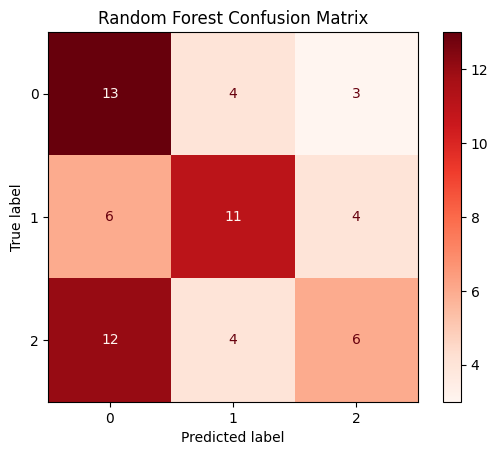

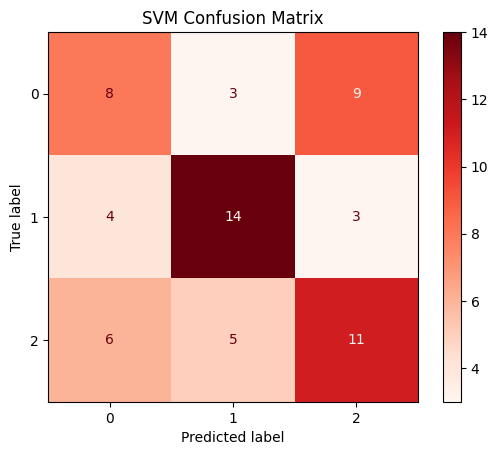

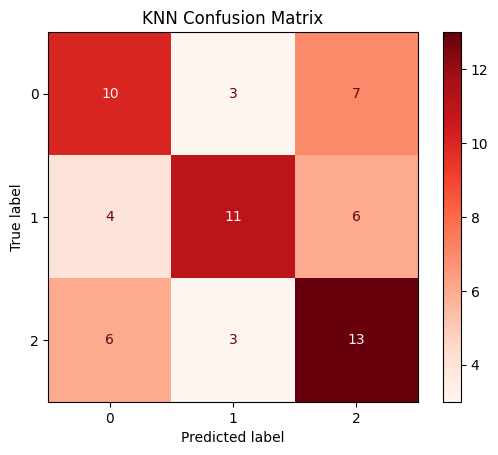

In [48]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Reds)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(x_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(x_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(x_test), "KNN Confusion Matrix")

Kode di bawah ini digunakan untuk menampilkan tabel hasil dari setiap model klasifikasi.
Fungsi ini menerima empat parameter utama: y_true yang merupakan label sebenarnya dari data uji, serta rf_pred, svm_pred, dan knn_pred yang merupakan hasil prediksi dari masing-masing model, nama model akan ditampilkan sebagai "Random Forest", "SVM", dan "KNN".
Terdapat empat metrik evaluasi yang digunakan, yaitu Accuracy, Precision, Recall, dan F1-Score. Setiap metrik dikaitkan dengan fungsi evaluasinya dari library sklearn.metrics. Kemudian, dilakukan iterasi terhadap setiap model dan hasil prediksinya. Untuk setiap metrik, jika metrik tersebut termasuk Precision, Recall, atau F1-Score, maka evaluasi dilakukan menggunakan parameter average='weighted', yang cocok digunakan untuk data dengan lebih dari dua kelas (multiclass classification). Sementara untuk Accuracy, cukup menggunakan fungsi evaluasi standar tanpa parameter tambahan.

Hasil evaluasi setiap metrik dari masing-masing model disimpan dalam sebuah dictionary comparison_data. Dictionary ini kemudian diubah menjadi sebuah objek pandas.DataFrame dan ditransposisikan (.T) agar model menjadi baris dan metrik menjadi kolom. Lalu, tabel ditampilkan dengan menggunakan fungsi display

In [49]:
#Tabel Perbandingan
def display_model_comparison(y_true, rf_pred, svm_pred, knn_pred, model_names=['Random Forest', 'SVM', 'KNN']):
    
    metrics = {
        'Accuracy': accuracy_score,
        'Precision': precision_score,
        'Recall': recall_score,
        'F1-Score': f1_score
    }

    comparison_data = {}

    for name, pred in zip(model_names, [rf_pred, svm_pred, knn_pred]):
        comparison_data[name] = {}
        for metric_name, metric_func in metrics.items():
            if metric_name in ['Precision', 'Recall', 'F1-Score']:
                scores = metric_func(y_true, pred, average='weighted')
                comparison_data[name][metric_name] = scores
            else:
                comparison_data[name][metric_name] = metric_func(y_true, pred)

    df_comparison = pd.DataFrame(comparison_data).T
    print("\nTABEL PERBANDINGAN MODEL")
    display(df_comparison)
# Display model comparison
rf_pred = rf.predict(x_test)
svm_pred = svm.predict(x_test)
knn_pred = knn.predict(x_test)
display_model_comparison(y_test, rf_pred, svm_pred, knn_pred)


TABEL PERBANDINGAN MODEL


,Accuracy,Precision,Recall,F1-Score
Random Forest,0.476190,0.487283,0.476190,0.464904
SVM,0.523810,0.520226,0.523810,0.521445
KNN,0.539683,0.549020,0.539683,0.540866
